<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/Logo_EICT_horizontal_ESPANOL%20(1).png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Algoritmo de Grover   </p> listas no estructuradas </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Tesis</p></tp>
            <tp><p style="font-size:115%;text-align:center">Maestría ICT 2025-2</p></tp>
            <tp><p style="font-size:115%;text-align:center">Stiven Paloma Alarcon</p></tp>
        </td>
    </tr>
</table>



# <FONT SIZE=5 COLOR="white"> **Aplicación del Algoritmo de Grover en búsquedas no estructuradas: análisis y comparación de la eficiencia de algoritmos de búsqueda con algoritmos cuánticos.** </FONT>

Las búsquedas en bases de datos no estructuradas o listas no ordenadas son un desafío esencial en la teoría de la computación, debido a la ausencia de un orden que permita aprovechar técnicas de optimización clásicas. En este tipo de problemas, la localización de un elemento que cumple una propiedad específica requiere, en el caso clásico, un análisis exhaustivo de los N elementos presentes en la base de datos, lo que implica un costo computacional promedio de O(N). Este límite se mantiene incluso con enfoques avanzados descritos en trabajos fundamentales de autores como Knuth (1998), quien en The Art of Computer Programming analiza a profundidad las técnicas de búsqueda lineal y sus limitaciones en ausencia de estructura (Knuth, 1998). De manera similar, Cormen, Leiserson, Rivest y Stein (2009) subrayan en Introduction to Algorithms que las búsquedas no estructuradas no pueden beneficiarse de optimizaciones derivadas de estructuras jerárquicas, como árboles de búsqueda o tablas hash, destacando que el rendimiento está limitado por la necesidad de inspeccionar cada elemento de manera secuencial. Por otro lado, Sedgewick (2011) y Wirth (1976) abordan estrategias relacionadas con la eficiencia en algoritmos de búsqueda, pero recalcan que los avances en estructuras de datos no eliminan la barrera inherente de O(N) para problemas sin orden. En este contexto, la computación cuántica ofrece una solución innovadora al problema de búsquedas no estructuradas. El Algoritmo de Grover, introducido en 1996, reduce el tiempo de búsqueda a O(√ N), logrando una aceleración cuadrática en comparación con los algoritmos clásicos. Esto se consigue mediante transformaciones iterativas basadas en la superposición cuántica y la interferencia constructiva, lo que amplifica la probabilidad del estado objetivo y atenúa las demás posibilidades (Grover, 1996). Este avance, sin embargo, enfrenta retos en su implementación práctica, como la preservación de la coherencia cuántica, el diseño de oráculos específicos para cada problema y la necesidad de puertas cuánticas de alta fidelidad. Este proyecto se centra en la implementación del Algoritmo Cuántico de Grover, donde se explorará en simulaciones de computación cuántica con apoyo del lenguaje Qiskit, contribuyendo a una comprensión más profunda de cómo estas técnicas pueden resolver problemas fundamentales de búsqueda con mayor eficiencia. El análisis combinado de estas limitaciones clásicas y los avances cuánticos pone de manifiesto el potencial transformador del Algoritmo de Grover para problemas de búsqueda en bases de datos no estructuradas, aportando una perspectiva novedosa que supera los enfoques tradicionales estudiados por autores como Knuth, Cormen et al., Sedgewick y Wirth.




In [37]:
#pip install requerimientos.txt

In [2]:
#La usamos para calcular el número optimo de iteraciones de Grover
import math

#Nos permite definir el tipo de dato para las cláusulas de 3-SAT
from typing import List, Tuple

#Nos permite trabajar con matrices y vectores, procesar las probabilidades y graficar resultados
import numpy as np

#Genera números aleatorios
import random

#Se usa para graficar resultados como histogramas, matroces de densidad, entre otros
import matplotlib.pyplot as plt

# QuantumCircuit: para construir tu circuito cuántico (el núcleo de tu algoritmo)
#QuantumRegister: crea registros de qubits (variables, cláusulas, ancillas)
#transpile: adapta el circuito al backend físico, optimizando para restricciones reales
from qiskit import QuantumCircuit, QuantumRegister, transpile

#Función para graficar los resultados de las mediciones del circuito
from qiskit.visualization import plot_histogram

#DensityMatrix: representa estados mixtos (útil después de traza parcial)
#Statevector: representa estados puros del sistema cuántico
#partial_trace: elimina qubits ancilla, quedándose solo con la información de los qubits relevantes (variables en 3-SAT)
from qiskit.quantum_info import DensityMatrix, Statevector, partial_trace

#Implementa una puerta multi-control NOT (Toffoli generalizada)
from qiskit.circuit.library import MCXGate

#Aer: permite usar simuladores cuánticos locales o configurables
#AerSimulator: simulador especializado, configurable con diferentes métodos (statevector, density_matrix, etc.). Fundamental para ejecutar y depurar tu circuito antes de enviarlo a un backend real
from qiskit_aer import Aer
from qiskit_aer import AerSimulator

#Para declarar registros clásicos necesarios para medir y almacenar los resultados del circuito cuántico
from qiskit import ClassicalRegister

#Proporciona una forma moderna de ejecutar circuitos y obtener estadísticas de salida
#from qiskit.primitives import Sampler
#Permite conectarse con dispositivos cuánticos reales de IBM, gestiona el acceso con tokens, instancia, elección de backend, ejecución de trabajos reales
from qiskit_ibm_runtime import QiskitRuntimeService

#Para mostrar objetos visuales dentro de notebooks interactivos
from IPython.display import display
# Asegura import si no está
from typing import List 


 Definición del Problema 3-SAT y Verificación Clásica

## Referencias

[1] IBM Quantum Learning. (2024). *Grover's algorithm*. Recuperado el 3 de octubre de 2025, de https://learning.quantum.ibm.com/tutorial/grovers-algorithm

[2] Vinod, G. M., & Shaji, A. (2022). Finding solutions to the integer case constraint satisfiability problem using Grover’s algorithm. *arXiv preprint arXiv:2106.09976v2*. https://doi.org/10.48550/arXiv.2106.09976

[3] Pokharel, B., & Lidar, D. A. (2022). Better-than-classical Grover search via quantum error detection and suppression. *arXiv preprint arXiv:2211.04543v1*. https://doi.org/10.48550/arXiv.2211.04543

In [3]:
#Problema 3-SAT 

"""Este código define tipos estructurados usando typing, una cláusula (Clause) es una lista de tuplas donde cada tupla representa un literal:

int: el índice de la variable (por ejemplo, 0 representa x₀)
bool: si es True, el literal está negado (representa ¬x); si es False, es positivo (representa x).

Una fórmula en forma normal conjuntiva (CNF) es una lista de cláusulas. Por tanto, cada fórmula lógica será: C1​∧C2​∧...∧Cm​"""

Clause = List[Tuple[int, bool]]
CNF = List[Clause]


#Se definen 4 variables booleanas (x₀, x₁, x₂, x₃), necesarias para construir un oráculo de Grover con 4 qubits
#Una fórmula 3-SAT de 4 cláusulas. Cada cláusula contiene exactamente 3 literales, como es en 3-SAT

n_vars_3sat = 4
clauses_3sat: CNF = [
    [(0, False), (1, True), (2, False)],    # (x ∨ ¬y ∨ z)
    [(0, True), (1, False), (2, False)],   # (¬x ∨ y ∨ z)  
    [(0, True), (1, True), (3, True)],     # (¬x ∨ ¬y ∨ ¬w)
    [(1, False), (2, False), (3, False)]   # (y ∨ z ∨ w)
]

print(f"Problema 3-SAT definido con {n_vars_3sat} variables y {len(clauses_3sat)} cláusulas.")




#  Funciones para validar soluciones clásicamente
"""
Esta función evalúa una cláusula lógica sobre una asignación binaria assign_bits codificada como un entero.

Extrae el valor de cada variable con un bitshift y enmascaramiento.

Aplica la negación si es necesario (1 - bit para ¬x).

Si al menos un literal es verdadero, la cláusula se satisface (como define la disyunción ∨)."""

def eval_clause(assign_bits: int, clause: Clause) -> bool:
    for (vidx, is_neg) in clause:
        bit = (assign_bits >> vidx) & 1
        lit_true = (1 - bit) if is_neg else bit
        if lit_true == 1:
            return True
    return False

#Verifica si todas las cláusulas se satisfacen bajo una asignación dada

def eval_cnf(assign_bits: int, cnf: CNF) -> bool:
    return all(eval_clause(assign_bits, c) for c in cnf)

#Explora todas las posibles asignaciones binarias, guardando aquellas que satisfacen la formula con ayuda de la función eval_cnf

def find_all_solutions(cnf: CNF, n: int) -> List[int]:
    solutions = []
    for assignment in range(1 << n):
        if eval_cnf(assignment, cnf):
            solutions.append(assignment)
    return solutions



#Encontrar y mostrar las soluciones, se imprime la representación binaria invertida del número
#Esta representación será usada para comparar con los resultados medidos del circuito cuántico

solutions_clasicas = find_all_solutions(clauses_3sat, n_vars_3sat)
M = len(solutions_clasicas)

print(f"\nSe encontraron {M} soluciones clásicas:")
for sol in solutions_clasicas:
    #  (x,y,z,w -> w,z,y,x)
    bin_rep = format(sol, f'0{n_vars_3sat}b')
    print(f"  - Asignación: {bin_rep} (decimal: {sol})")

Problema 3-SAT definido con 4 variables y 4 cláusulas.

Se encontraron 9 soluciones clásicas:
  - Asignación: 0011 (decimal: 3)
  - Asignación: 0100 (decimal: 4)
  - Asignación: 0101 (decimal: 5)
  - Asignación: 0110 (decimal: 6)
  - Asignación: 0111 (decimal: 7)
  - Asignación: 1000 (decimal: 8)
  - Asignación: 1100 (decimal: 12)
  - Asignación: 1101 (decimal: 13)
  - Asignación: 1110 (decimal: 14)


Construcción de los Componentes Cuánticos

## Referencias

[1] IBM Quantum Learning. (2024). *Grover's algorithm*. Recuperado el 4 de octubre de 2025, de https://learning.quantum.ibm.com/tutorial/grovers-algorithm

[2] Vinod, G. M., & Shaji, A. (2022). Finding solutions to the integer case constraint satisfiability problem using Grover’s algorithm. *arXiv preprint arXiv:2106.09976v2 [quant-ph]*. https://doi.org/10.48550/arXiv.2106.09976

[3] Pokharel, B., & Lidar, D. A. (2022). Better-than-classical Grover search via quantum error detection and suppression. *arXiv preprint arXiv:2211.04543v1 [quant-ph]*. https://doi.org/10.48550/arXiv.2211.04543

[4] Grover, L. K. (1996). A fast quantum mechanical algorithm for database search. *Proceedings of the Twenty-Eighth Annual ACM Symposium on Theory of Computing (STOC '96)*, 212–219. https://doi.org/10.1145/237814.237866

In [4]:
"""
Implementa una multi-controlled X (MCX) en donde algunos controles pueden ser negados
Lógica:

Aplica X gates temporales en los controles cuyo literal esté negado (¬x) para invertir su lógica, aplica la puerta mcx y deshace las X para restaurar el estado inicial.Esto permite implementar 
condiciones lógicas como conjunciones con literales negados, es decir, cláusulas del tipo:
(x ∨ ¬y ∨ z) se traduce a controles [x, y, z] con máscara de negación [False, True, False] de forma reversible y no destructiva."""


def mcx_with_polarities(qc: QuantumCircuit, controls, target, neg_mask: List[bool]):
    """MCX con controles potencialmente negados mediante X temporales"""
    # Aplicar X en controles negados ANTES
    for ctrl, neg in zip(controls, neg_mask):
        if neg:
            qc.x(ctrl)
    # MCX
    qc.mcx(controls, target)
    # Deshacer X en controles negados DESPUÉS (mismo orden, NO reversed)
    for ctrl, neg in zip(controls, neg_mask): 
        if neg:
            qc.x(ctrl)

"""Evalúa si al menos un literal en la cláusula es verdadero (operación OR) y guarda el resultado en un qubit ancilla (target).

Estrategia:
Inicializa el target en |1⟩ (lo que se espera para OR verdadero). Luego lo invierte a |0⟩ sólo si todos los literales son falsos, usando un truco con negaciones y mcx.
La operación es completamente reversible, una necesidad fundamental para descomputar luego y evitar residuos cuánticos. Este enfoque permite construir un oráculo que no colapsa el estado.
"""

# FUNCIÓN AUXILIAR
def compute_clause_or(qc: QuantumCircuit, controls: list, target: int, neg_mask: list[bool]):
    """
    Computa OR reversible de literales en target: set=1 si >=1 literal verdadero (ajustado por neg_mask).
    - Reversible: descomputa igual (llamar dos veces resetea a |0>).
    - Usa trick: init target=1, flip a 0 si todos falsos (mcx en negated).
    """
    # Ajustar polaridad: X en literales negados (¬x -> x para OR positivo)
    for ctrl, neg in zip(controls, neg_mask):
        if neg:
            qc.x(ctrl)
    # Init target=1 (asumiendo |0> inicial, X lo pone en 1)
    qc.x(target)
    # Negar todos controls temp (1 si literal falso)
    negated_ctrls = controls[:]  # Copia lista
    for c in negated_ctrls:
        qc.x(c)
    # MCX: flip target si todos negated=1 -> target=0 si OR=0
    qc.mcx(negated_ctrls, target)
    # Deshacer negación de controls
    for c in negated_ctrls:
        qc.x(c)
    # Deshacer polaridad de literales
    for ctrl, neg in zip(controls, neg_mask):
        if neg:
            qc.x(ctrl)

"""
Estructura del circuito:

n_vars: número de cúbits de variables (4)
cnf: lista de cláusulas del problema.

Registros cuánticos:

var_reg: cúbits que representan las variables booleanas (superposición)
clause_reg: cúbits ancilla que guardan si cada cláusula se satisface
g_reg: cúbit que guarda si todas las cláusulas son verdaderas
phase_reg: cúbit de fase, preparado en |−⟩ para inducir la inversión de fase

Registros Separados: Facilita modularidad y depuración (e.g., qc.draw() muestra layers claras), alineado con Qiskit best practices (tutorial IBM, pág. 2: usa QuantumRegister para semántica).
Alternativa única reg (todos qubits) es más compacta pero menos legible para NISQ (routing overhead); esto minimiza crosstalk en hardware.

| Paso | Acción                                       | Justificación                                                |                                                         |
| ---- | -------------------------------------------- | ------------------------------------------------------------ | ------------------------------------------------------- |
| 1    | Prepara `phase_reg` en                       | −⟩                                                           | Necesario para que el `CZ` actúe como inversión de fase |
| 2    | Evalúa cada cláusula con `compute_clause_or` | Marca qué cláusulas son verdaderas                           |                                                         |
| 3    | Aplica `mcx` sobre `clause_reg` → `g_reg`    | Detecta si **todas** las cláusulas son verdaderas            |                                                         |
| 4    | Aplica `CZ(g, phase)`                        | Inversión de fase condicional (marca las soluciones válidas) |                                                         |
| 5    | Deshace `mcx` sobre `g_reg`                  | Limpia el cúbit global                                       |                                                         |
| 6    | Descomputa cláusulas (reversible OR)         | Restaura ancillas a                                          | 0⟩                                                      |
| 7    | Restaura `phase_reg` a                       | 0⟩                                                           | Limpia la inversión de fase                             |

"""




def build_robust_3sat_oracle(n_vars: int, cnf: CNF) -> QuantumCircuit:
    """Oráculo 3-SAT usando diseño validado (INTEGRADO FIX: OR en cláusulas)"""
    m = len(cnf)
    var_reg = QuantumRegister(n_vars, 'x')
    clause_reg = QuantumRegister(m, 'c')
    g_reg = QuantumRegister(1, 'g')
    phase_reg = QuantumRegister(1, 'phase')
    
    qc = QuantumCircuit(var_reg, clause_reg, g_reg, phase_reg, name=f'Oracle_3SAT')
    
    # 1. Preparar phase qubit en |->
    qc.x(phase_reg[0])  # FIX
    qc.h(phase_reg[0])
    
    # 2. Computar cada cláusula en su propia ancilla (FIX: Reemplaza x + mcx por OR reversible)
    for i, clause in enumerate(cnf):
        controls = [var_reg[vidx] for (vidx, _) in clause]
        neg_mask = [is_neg for (_, is_neg) in clause]  # Máscara directa (True si ¬)
        compute_clause_or(qc, controls, clause_reg[i], neg_mask)  # FIX: Computa OR=1 si cláusula verdadera
    
    # 3. AND global de todas las cláusulas 
    if m > 0:
        qc.mcx(list(clause_reg), g_reg[0])
    
    # 4. Phase 
    qc.cz(g_reg[0], phase_reg[0])
    
    # 5. Descomputar AND global
    if m > 0:
        qc.mcx(list(clause_reg), g_reg[0])
    
    # 6. Descomputar cláusulas (orden inverso) (FIX: Reemplaza por OR reversible - es idempotente)
    for i, clause in reversed(list(enumerate(cnf))):
        controls = [var_reg[vidx] for (vidx, _) in clause]
        neg_mask = [is_neg for (_, is_neg) in clause]
        compute_clause_or(qc, controls, clause_reg[i], neg_mask)  # FIX: Descomputa OR (llamada doble resetea)
    
    # 7. Restaurar phase qubit a |0>
    qc.h(phase_reg[0])
    qc.x(phase_reg[0])
    
    return qc
"""

Descomposición Estándar: Para Grover (Grover, 1996; IBM tutorial, pág. 4), O(n) profundidad con MCX como bottleneck 
(descomponible en CCX para hardware). Alternativa con GroverOperator (Qiskit library) auto-genera, pero custom permite control fino (e.g., ancillas en MCX futuro); este es exacto para n=4.

Estructura:

H: transforma la base computacional a la base de Hadamard

X: invierte alrededor de |1⟩

H + MCX + H: invierte el estado |0⟩, completando el reflejo alrededor del promedio

X + H: invierte el efecto anterior
"""

def build_diffuser(n_vars: int) -> QuantumCircuit:
    """Construye el operador de difusión de Grover para n_vars cúbits (sin cambios - ya óptimo)"""
    qc = QuantumCircuit(n_vars, name="Difusor")
    qc.h(range(n_vars))
    qc.x(range(n_vars))
    qc.h(n_vars - 1)
    qc.mcx(list(range(n_vars - 1)), n_vars - 1)
    qc.h(n_vars - 1)
    qc.x(range(n_vars))
    qc.h(range(n_vars))
    return qc

In [5]:
# CONSTRUCCIÓN Y VERIFICACIÓN
oracle_correcto = build_robust_3sat_oracle(n_vars_3sat, clauses_3sat)
print(f"\nORÁCULO CONSTRUIDO")


ORÁCULO CONSTRUIDO


Ensamblaje del Algoritmo de Grover Completo

Parámetros de Grover: N=16, M=9, Iteraciones óptimas (k)=2

Circuito completo de Grover ensamblado.


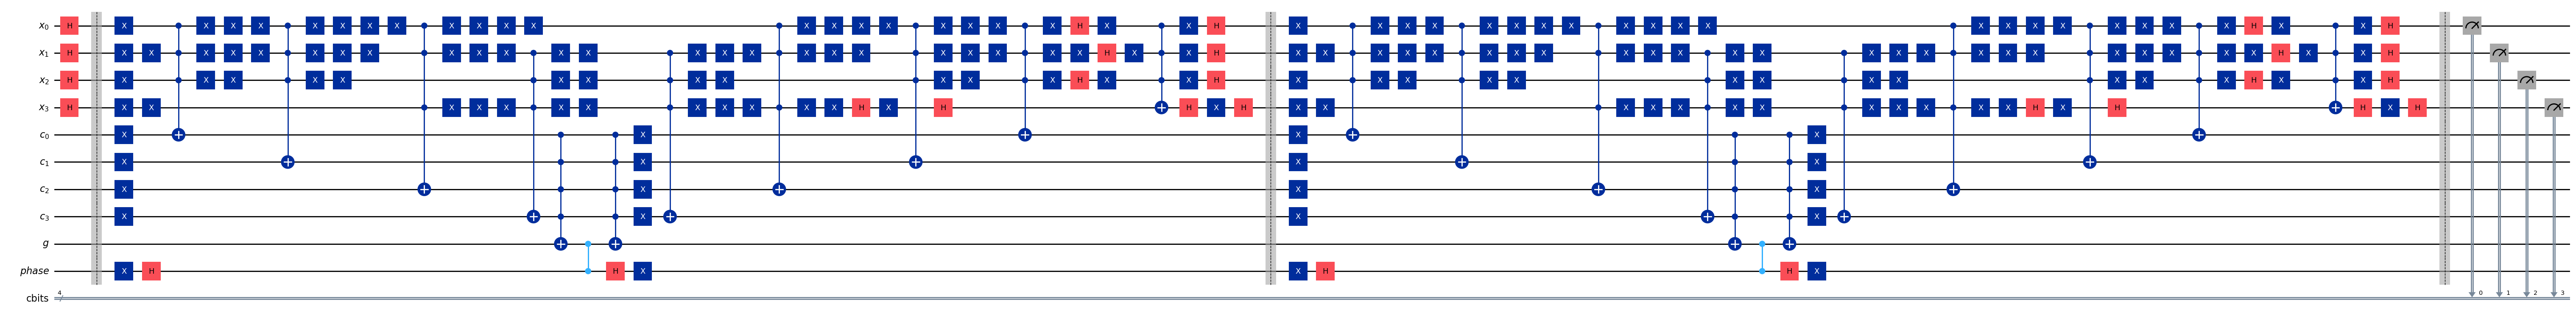

In [33]:
# Componentes
oracle = build_robust_3sat_oracle(n_vars_3sat, clauses_3sat)
diffuser = build_diffuser(n_vars_3sat)
#k = 3

# Calcular número óptimo de iteraciones
"""N = 2**n_vars_3sat

if M > 0:
    k = round((math.pi / 4) * math.sqrt(N / M))

print(f"Parámetros de Grover: N={N}, M={M}, Iteraciones óptimas (k  )={k}")"""

# Ajusta esta línea donde defines 'k'
user_k = 2
k = user_k if user_k else round((math.pi / 4) * math.sqrt(N / M))
print(f"Parámetros de Grover: N={2**n_vars_3sat}, M={M}, Iteraciones óptimas (k)={k}")


# Crear el circuito final
var_reg = oracle.qregs[0]
clause_reg = oracle.qregs[1]
g_reg = oracle.qregs[2]
phase_reg = oracle.qregs[3]
creg = ClassicalRegister(n_vars_3sat, 'cbits')

grover_circuit = QuantumCircuit(var_reg, clause_reg, g_reg, phase_reg, creg)

# Inicializar estado de superposición uniforme en variables
grover_circuit.h(var_reg)
grover_circuit.barrier()

# 2. Aplicar k iteraciones de Grover
for i in range(k):
    grover_circuit.compose(oracle, inplace=True)
    # El difusor solo actúa sobre los cúbits de variables
    grover_circuit.compose(diffuser, qubits=var_reg, inplace=True)
    grover_circuit.barrier()

# 3. Medir los cúbits de variables
grover_circuit.measure(var_reg, creg)

print("\nCircuito completo de Grover ensamblado.")
# Diagrama
grover_circuit.draw('mpl', fold=-1)

 Simulación, Ejecución y Análisis de Resultados

Ejecutando simulación con 4096 shots...
Simulación completada.

 ANÁLISIS DE RESULTADOS
Soluciones clásicas esperadas: ['1100', '0010', '1010', '0110', '1110', '0001', '0011', '1011', '0111']

Resultados más frecuentes de la simulación:
  - Estado |1000⟩ (Decimal: 8): 335 veces ¡ES SOLUCIÓN!
  - Estado |0011⟩ (Decimal: 3): 327 veces ¡ES SOLUCIÓN!
  - Estado |0101⟩ (Decimal: 5): 323 veces ¡ES SOLUCIÓN!
  - Estado |1100⟩ (Decimal: 12): 315 veces ¡ES SOLUCIÓN!
  - Estado |0110⟩ (Decimal: 6): 312 veces ¡ES SOLUCIÓN!
  - Estado |0111⟩ (Decimal: 7): 308 veces ¡ES SOLUCIÓN!
  - Estado |1101⟩ (Decimal: 13): 303 veces ¡ES SOLUCIÓN!
  - Estado |0100⟩ (Decimal: 4): 302 veces ¡ES SOLUCIÓN!
  - Estado |1110⟩ (Decimal: 14): 280 veces ¡ES SOLUCIÓN!
  - Estado |1001⟩ (Decimal: 9): 210 veces (Ruido o estado no-solución)
  - Estado |1011⟩ (Decimal: 11): 199 veces (Ruido o estado no-solución)

Probabilidad total de medir una solución correcta: 0.685 (2805/4096)


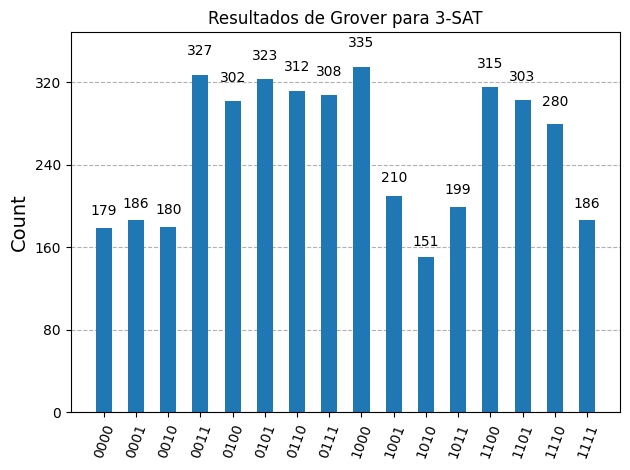

In [34]:
# 1. Preparar el simulador
backend = AerSimulator()
transpiled_circuit = transpile(grover_circuit, backend)
shots = 4096

# 2. Ejecutar la simulación
print(f"Ejecutando simulación con {shots} shots...")
result = backend.run(transpiled_circuit, shots=shots).result()
counts = result.get_counts()
print("Simulación completada.")

# 3. Analizar y validar los resultados
print("\n ANÁLISIS DE RESULTADOS")
print("Soluciones clásicas esperadas:", [format(s, f'0{n_vars_3sat}b')[::-1] for s in solutions_clasicas])

# Ordenar los resultados por el número de mediciones
sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)

print("\nResultados más frecuentes de la simulación:")
total_correct_shots = 0
for state, count in sorted_counts[:M+2]: # Mostramos las M+2 más probables
    # El estado en 'counts' está en formato little-endian, lo dejamos como está
    state_decimal = int(state, 2)
    
    # Validamos si el resultado es una solución real
    if state_decimal in solutions_clasicas:
        print(f"  - Estado |{state}⟩ (Decimal: {state_decimal}): {count} veces ¡ES SOLUCIÓN!")
        total_correct_shots += count
    else:
        print(f"  - Estado |{state}⟩ (Decimal: {state_decimal}): {count} veces (Ruido o estado no-solución)")

# 4. Calcular probabilidad de éxito
success_prob = total_correct_shots / shots
print(f"\nProbabilidad total de medir una solución correcta: {success_prob:.3f} ({total_correct_shots}/{shots})")

# 5. Visualizar el histograma
plot_histogram(counts, title="Resultados de Grover para 3-SAT")

# RESULTADO 3 IREACIONES

Ejecutando simulación para obtener el Statevector...
Generando City Plot de la Matriz de Densidad Final...


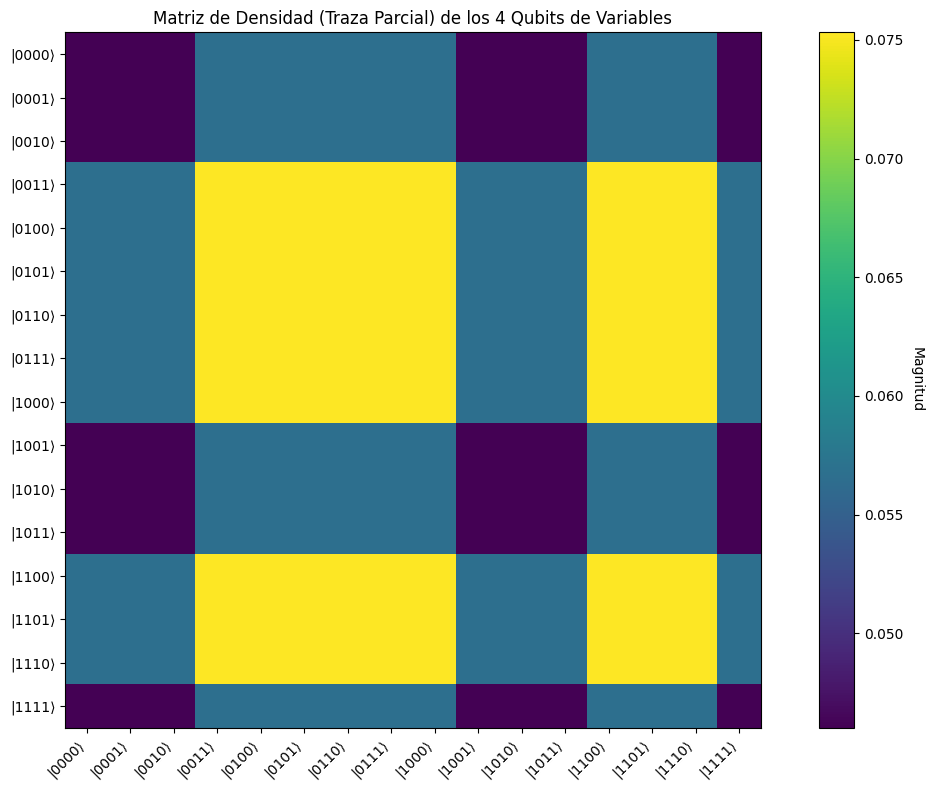


Información de la matriz de densidad:
Dimensiones de la matriz: 16
Traza de la matriz: 1.0000+0.0000j

Interpretación de la visualización:
- Los elementos diagonales muestran las probabilidades de medir cada estado base
- Los elementos fuera de la diagonal representan las coherencias cuánticas
- Los colores más brillantes indican valores más altos en magnitud

Probabilidades de los estados base:
Estado |0000⟩: 0.0460
Estado |0001⟩: 0.0460
Estado |0010⟩: 0.0460
Estado |0011⟩: 0.0753
Estado |0100⟩: 0.0753
Estado |0101⟩: 0.0753
Estado |0110⟩: 0.0753
Estado |0111⟩: 0.0753
Estado |1000⟩: 0.0753
Estado |1001⟩: 0.0460
Estado |1010⟩: 0.0460
Estado |1011⟩: 0.0460
Estado |1100⟩: 0.0753
Estado |1101⟩: 0.0753
Estado |1110⟩: 0.0753
Estado |1111⟩: 0.0460


In [35]:
# Crear una copia del circuito de Grover y prepararla para la simulación de estado ---
grover_for_sv = grover_circuit.remove_final_measurements(inplace=False)

# AÑADIMOS LA INSTRUCCIÓN CLAVE:
grover_for_sv.save_statevector() 

#  2. Configurar el simulador y ejecutar 
backend_sv = AerSimulator(method='statevector')
transpiled_sv_circuit = transpile(grover_for_sv, backend_sv)

print("Ejecutando simulación para obtener el Statevector...")
job_sv = backend_sv.run(transpiled_sv_circuit)
result_sv = job_sv.result()

# 3. Obtener el vector de estado y la matriz de densidad ---
final_statevector = result_sv.get_statevector()
# Creamos la matriz de densidad
state_dm = DensityMatrix(final_statevector)

#  Dibujar la City Plot
print("Generando City Plot de la Matriz de Densidad Final...")

# Filtramos los qubits para visualizar solo los de las variables
qubits_to_keep = list(range(n_vars_3sat))  
qubits_to_trace = list(range(n_vars_3sat, grover_for_sv.num_qubits))

# Realizamos la traza parcial sobre los qubits que no queremos visualizar
partial_dm = partial_trace(state_dm, qubits_to_trace)

# Configuración específica de matplotlib
plt.clf()  
plt.close('all') 

# Obtener los datos de la matriz
matrix_data = partial_dm.data
matrix_size = matrix_data.shape[0]

# Crear nueva figura con subplots
fig, ax = plt.subplots(figsize=(12, 8))

# Crear el mapa de calor
im = ax.imshow(np.abs(matrix_data), cmap='viridis')

# Configurar etiquetas de ejes
ax.set_xticks(range(matrix_size))
ax.set_yticks(range(matrix_size))
ax.set_xticklabels([f'|{format(i, f"0{n_vars_3sat}b")}⟩' for i in range(matrix_size)])
ax.set_yticklabels([f'|{format(i, f"0{n_vars_3sat}b")}⟩' for i in range(matrix_size)])

# Rotar las etiquetas para mejor visualización
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

# Agregar barra de color
cbar = plt.colorbar(im)
cbar.set_label('Magnitud', rotation=270, labelpad=15)

# Título
plt.title(f"Matriz de Densidad (Traza Parcial) de los {n_vars_3sat} Qubits de Variables")

# Ajustar el layout
plt.tight_layout()

# Mostrar
plt.show()

# Imprimir información
print("\nInformación de la matriz de densidad:")
print(f"Dimensiones de la matriz: {partial_dm.dim}")
print(f"Traza de la matriz: {np.trace(partial_dm.data):.4f}")

print("\nInterpretación de la visualización:")
print("- Los elementos diagonales muestran las probabilidades de medir cada estado base")
print("- Los elementos fuera de la diagonal representan las coherencias cuánticas")
print("- Los colores más brillantes indican valores más altos en magnitud")

# Mostrar las probabilidades de los estados base
probs = np.real(np.diag(partial_dm.data))
print("\nProbabilidades de los estados base:")
for i, prob in enumerate(probs):
    if prob > 0.01:  # Solo mostrar probabilidades significativas
        print(f"Estado |{format(i, f'0{n_vars_3sat}b')}⟩: {prob:.4f}")

# RESULTADO 1 ITERACION

Ejecutando simulación para obtener el Statevector...
Generando City Plot de la Matriz de Densidad Final...


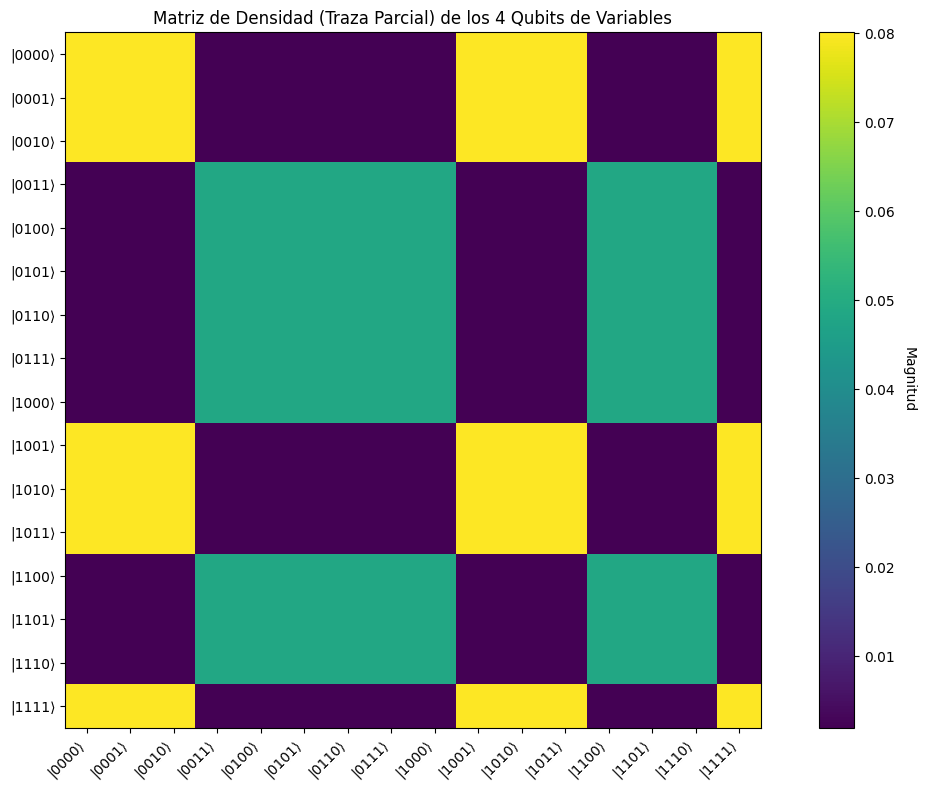


Información de la matriz de densidad:
Dimensiones de la matriz: 16
Traza de la matriz: 1.0000-0.0000j

Interpretación de la visualización:
- Los elementos diagonales muestran las probabilidades de medir cada estado base
- Los elementos fuera de la diagonal representan las coherencias cuánticas
- Los colores más brillantes indican valores más altos en magnitud

Probabilidades de los estados base:
Estado |0000⟩: 0.0801
Estado |0001⟩: 0.0801
Estado |0010⟩: 0.0801
Estado |0011⟩: 0.0488
Estado |0100⟩: 0.0488
Estado |0101⟩: 0.0488
Estado |0110⟩: 0.0488
Estado |0111⟩: 0.0488
Estado |1000⟩: 0.0488
Estado |1001⟩: 0.0801
Estado |1010⟩: 0.0801
Estado |1011⟩: 0.0801
Estado |1100⟩: 0.0488
Estado |1101⟩: 0.0488
Estado |1110⟩: 0.0488
Estado |1111⟩: 0.0801


In [26]:
# Crear una copia del circuito de Grover y prepararla para la simulación de estado ---
grover_for_sv = grover_circuit.remove_final_measurements(inplace=False)

# AÑADIMOS LA INSTRUCCIÓN CLAVE:
grover_for_sv.save_statevector() 

#  2. Configurar el simulador y ejecutar 
backend_sv = AerSimulator(method='statevector')
transpiled_sv_circuit = transpile(grover_for_sv, backend_sv)

print("Ejecutando simulación para obtener el Statevector...")
job_sv = backend_sv.run(transpiled_sv_circuit)
result_sv = job_sv.result()

# 3. Obtener el vector de estado y la matriz de densidad ---
final_statevector = result_sv.get_statevector()
# Creamos la matriz de densidad
state_dm = DensityMatrix(final_statevector)

#  Dibujar la City Plot
print("Generando City Plot de la Matriz de Densidad Final...")

# Filtramos los qubits para visualizar solo los de las variables
qubits_to_keep = list(range(n_vars_3sat))  
qubits_to_trace = list(range(n_vars_3sat, grover_for_sv.num_qubits))

# Realizamos la traza parcial sobre los qubits que no queremos visualizar
partial_dm = partial_trace(state_dm, qubits_to_trace)

# Configuración específica de matplotlib
plt.clf()  
plt.close('all') 

# Obtener los datos de la matriz
matrix_data = partial_dm.data
matrix_size = matrix_data.shape[0]

# Crear nueva figura con subplots
fig, ax = plt.subplots(figsize=(12, 8))

# Crear el mapa de calor
im = ax.imshow(np.abs(matrix_data), cmap='viridis')

# Configurar etiquetas de ejes
ax.set_xticks(range(matrix_size))
ax.set_yticks(range(matrix_size))
ax.set_xticklabels([f'|{format(i, f"0{n_vars_3sat}b")}⟩' for i in range(matrix_size)])
ax.set_yticklabels([f'|{format(i, f"0{n_vars_3sat}b")}⟩' for i in range(matrix_size)])

# Rotar las etiquetas para mejor visualización
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

# Agregar barra de color
cbar = plt.colorbar(im)
cbar.set_label('Magnitud', rotation=270, labelpad=15)

# Título
plt.title(f"Matriz de Densidad (Traza Parcial) de los {n_vars_3sat} Qubits de Variables")

# Ajustar el layout
plt.tight_layout()

# Mostrar
plt.show()

# Imprimir información
print("\nInformación de la matriz de densidad:")
print(f"Dimensiones de la matriz: {partial_dm.dim}")
print(f"Traza de la matriz: {np.trace(partial_dm.data):.4f}")

print("\nInterpretación de la visualización:")
print("- Los elementos diagonales muestran las probabilidades de medir cada estado base")
print("- Los elementos fuera de la diagonal representan las coherencias cuánticas")
print("- Los colores más brillantes indican valores más altos en magnitud")

# Mostrar las probabilidades de los estados base
probs = np.real(np.diag(partial_dm.data))
print("\nProbabilidades de los estados base:")
for i, prob in enumerate(probs):
    if prob > 0.01:  # Solo mostrar probabilidades significativas
        print(f"Estado |{format(i, f'0{n_vars_3sat}b')}⟩: {prob:.4f}")

# RESULTADO 3 ITERACIONES 

Ejecutando simulación para obtener el Statevector...
Simulación completada.
Generando 'City Plot' de la Matriz de Densidad...


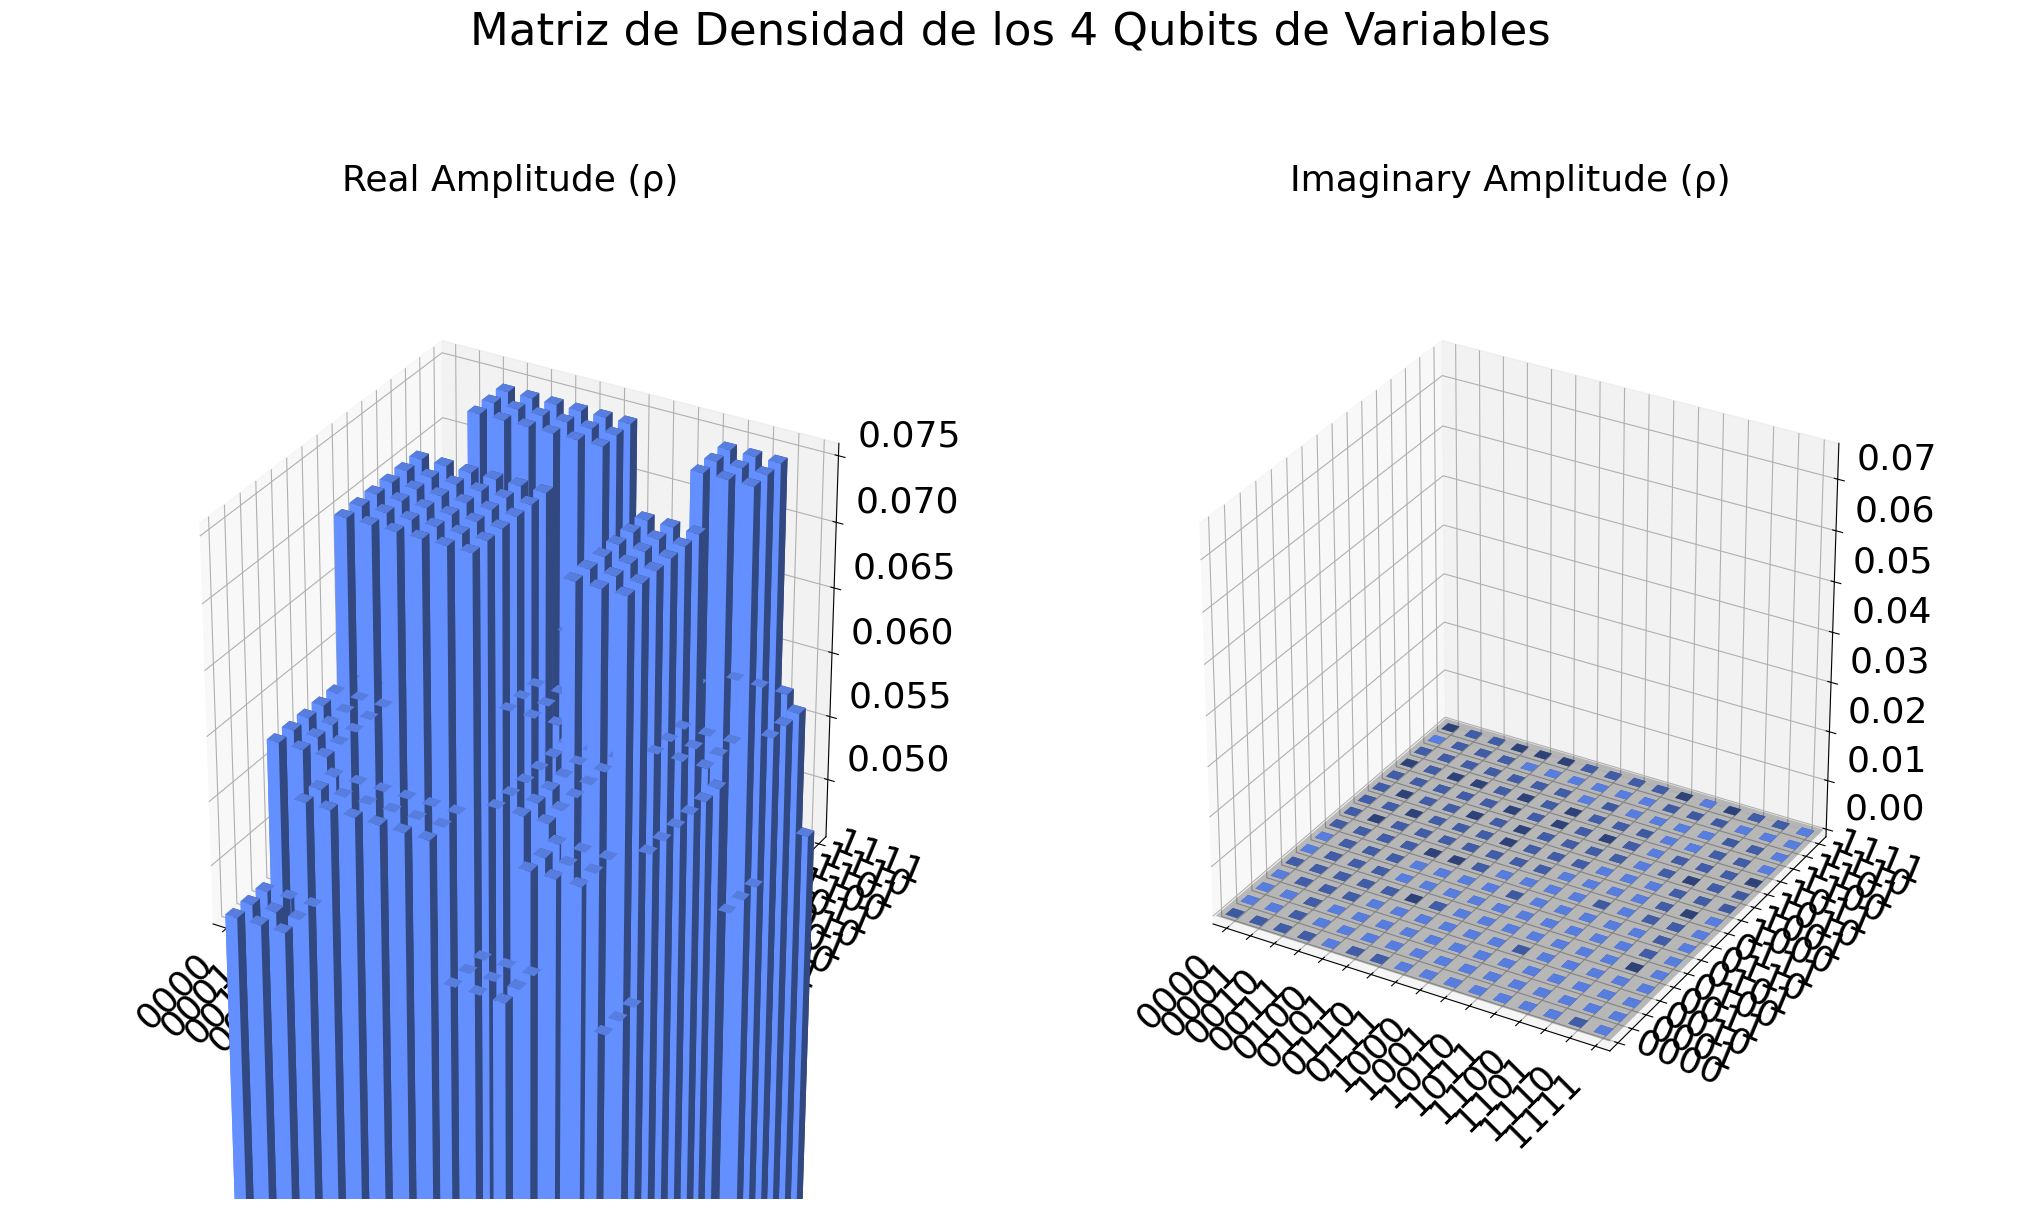

In [40]:

%matplotlib inline

#Preparar el circuito para la simulación de estado
grover_circuit_for_sv = grover_circuit.remove_final_measurements(inplace=False)
grover_circuit_for_sv.save_statevector()

# 2. Simular el circuito
backend_sv = AerSimulator()
transpiled_sv_circuit = transpile(grover_circuit_for_sv, backend_sv)
print("Ejecutando simulación para obtener el Statevector...")
result_sv = backend_sv.run(transpiled_sv_circuit).result()
print("Simulación completada.")

# 3. Obtener el vector de estado y la matriz de densidad completa
final_statevector = result_sv.get_statevector()
full_density_matrix = DensityMatrix(final_statevector)

# 4. Usar Trace Parcial para enfocarnos en los cúbits de variables ---
print("Generando 'City Plot' de la Matriz de Densidad...")
total_qubits = oracle_correcto.num_qubits
qubits_ancilla = list(range(n_vars_3sat, total_qubits))
partial_density_matrix = partial_trace(full_density_matrix, qubits_ancilla)

# 5. Dibujar la 'City Plot' 
partial_density_matrix.draw('city', figsize=(20, 13), title=f"Matriz de Densidad de los {n_vars_3sat} Qubits de Variables")





# RESULTADO 1 ITERACION 

Ejecutando simulación para obtener el Statevector...
Simulación completada.
Generando 'City Plot' de la Matriz de Densidad...


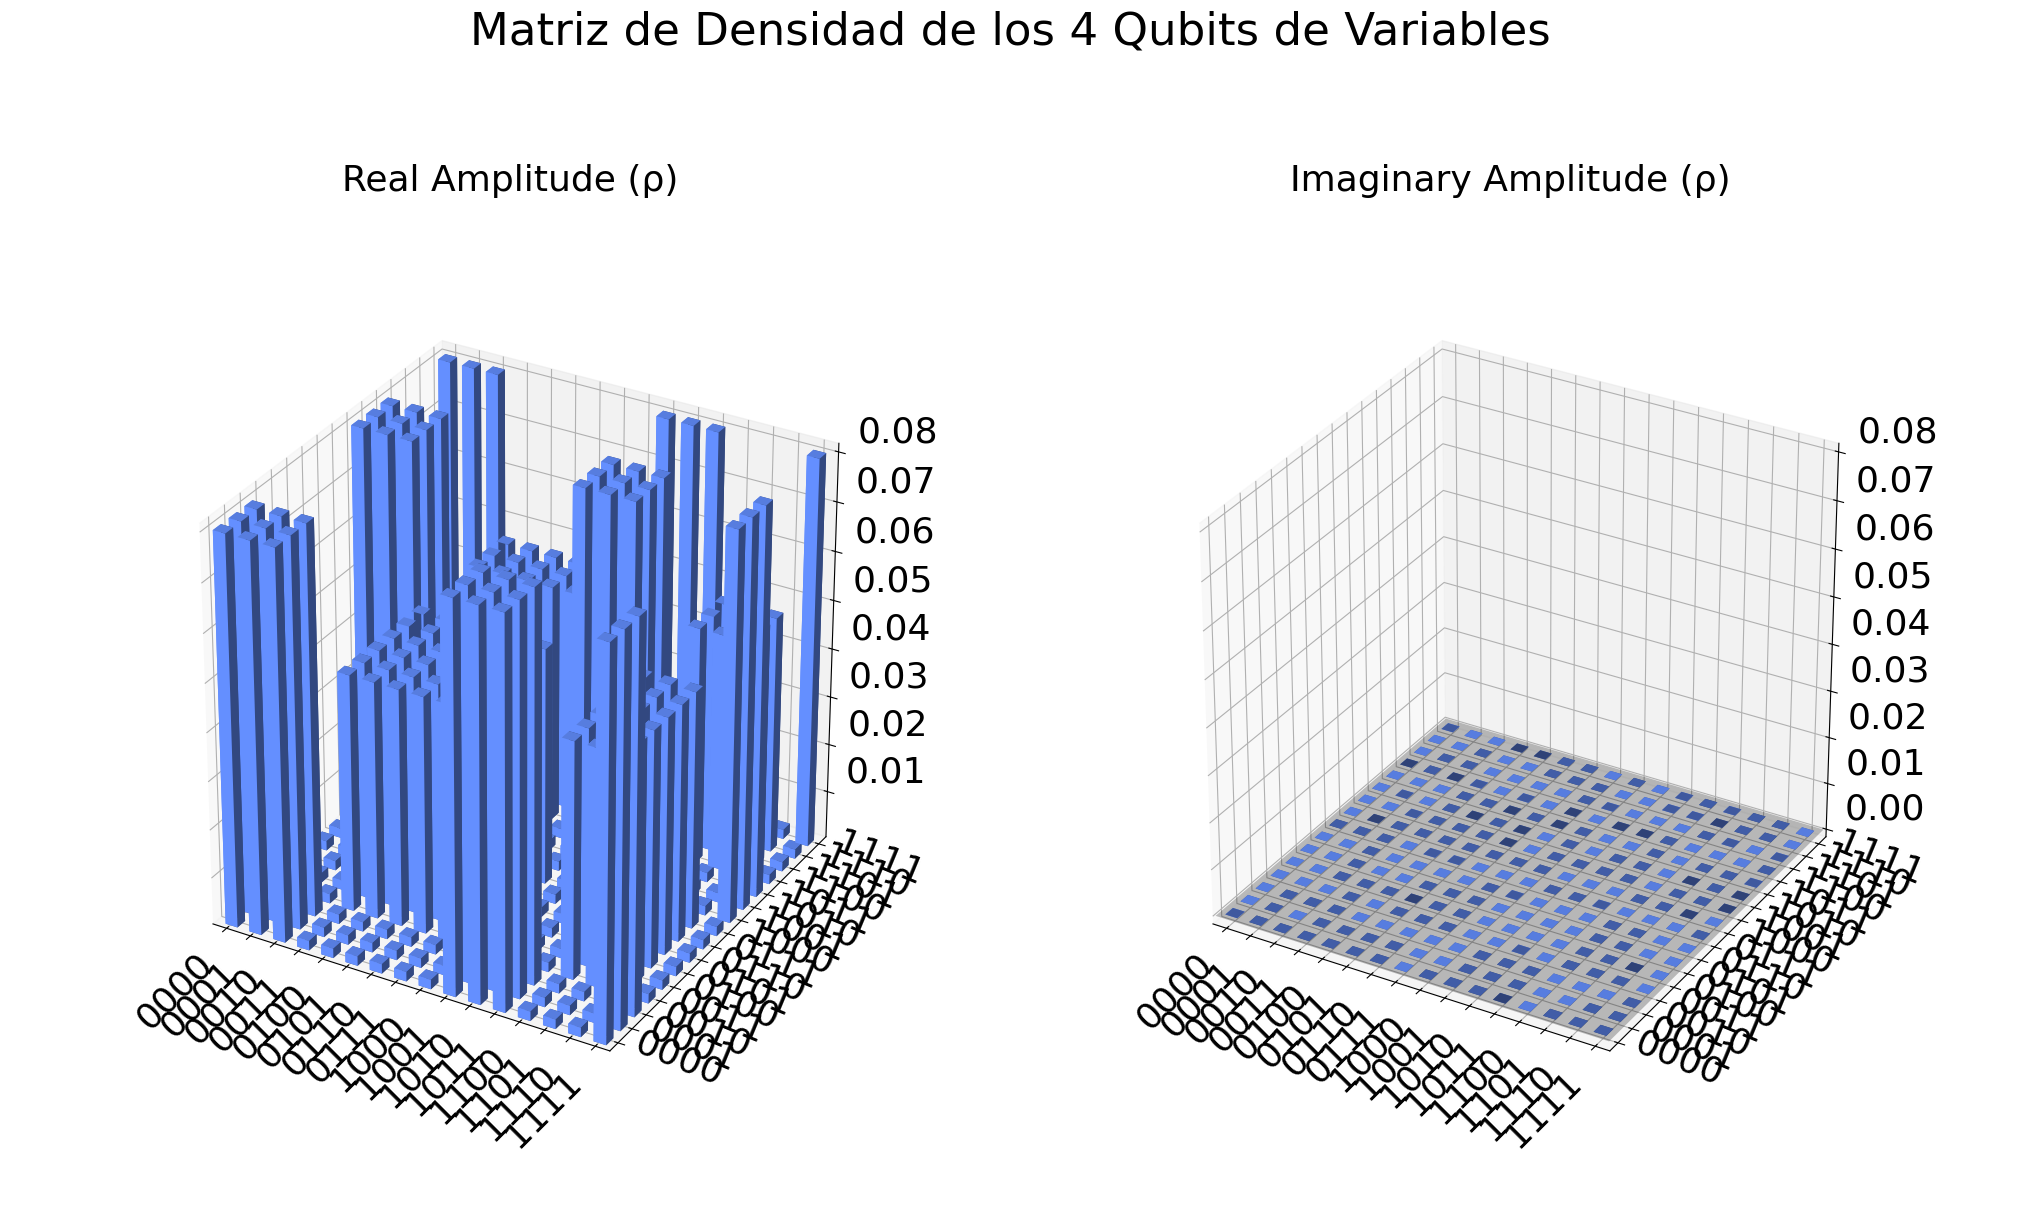

In [27]:

%matplotlib inline

#Preparar el circuito para la simulación de estado
grover_circuit_for_sv = grover_circuit.remove_final_measurements(inplace=False)
grover_circuit_for_sv.save_statevector()

# 2. Simular el circuito
backend_sv = AerSimulator()
transpiled_sv_circuit = transpile(grover_circuit_for_sv, backend_sv)
print("Ejecutando simulación para obtener el Statevector...")
result_sv = backend_sv.run(transpiled_sv_circuit).result()
print("Simulación completada.")

# 3. Obtener el vector de estado y la matriz de densidad completa
final_statevector = result_sv.get_statevector()
full_density_matrix = DensityMatrix(final_statevector)

# 4. Usar Trace Parcial para enfocarnos en los cúbits de variables ---
print("Generando 'City Plot' de la Matriz de Densidad...")
total_qubits = oracle_correcto.num_qubits
qubits_ancilla = list(range(n_vars_3sat, total_qubits))
partial_density_matrix = partial_trace(full_density_matrix, qubits_ancilla)

# 5. Dibujar la 'City Plot' 
partial_density_matrix.draw('city', figsize=(20, 13), title=f"Matriz de Densidad de los {n_vars_3sat} Qubits de Variables")


# PRUEBA CON DIFERENTES SHOTS 1028

Ejecutando simulación para obtener el Statevector...
Simulación completada.
Generando 'City Plot' de la Matriz de Densidad...


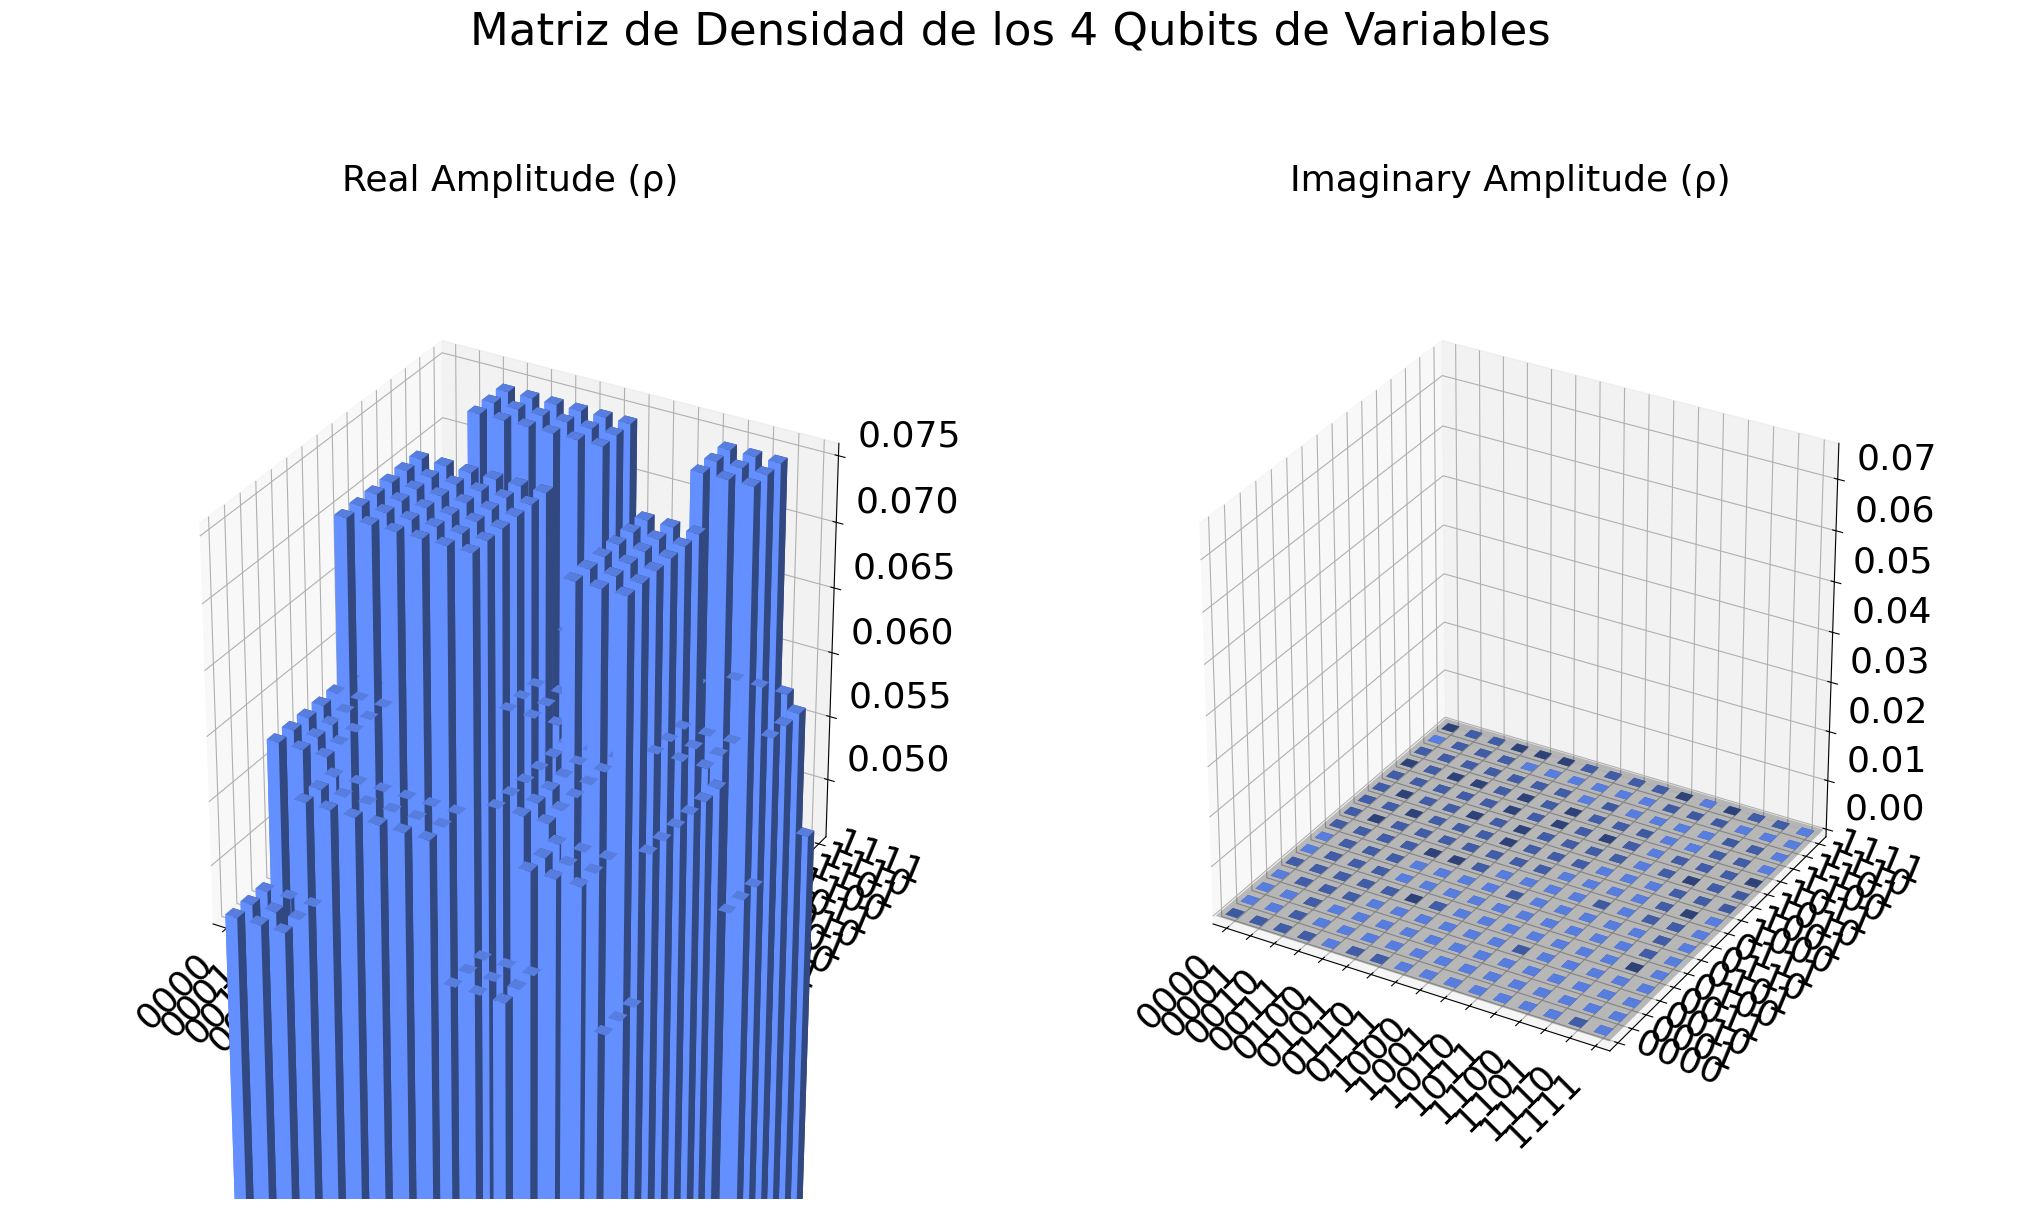

In [38]:

%matplotlib inline

#Preparar el circuito para la simulación de estado
grover_circuit_for_sv = grover_circuit.remove_final_measurements(inplace=False)
grover_circuit_for_sv.save_statevector()

# 2. Simular el circuito
backend_sv = AerSimulator()
transpiled_sv_circuit = transpile(grover_circuit_for_sv, backend_sv)
print("Ejecutando simulación para obtener el Statevector...")
result_sv = backend_sv.run(transpiled_sv_circuit).result()
print("Simulación completada.")

# 3. Obtener el vector de estado y la matriz de densidad completa
final_statevector = result_sv.get_statevector()
full_density_matrix = DensityMatrix(final_statevector)

# 4. Usar Trace Parcial para enfocarnos en los cúbits de variables ---
print("Generando 'City Plot' de la Matriz de Densidad...")
total_qubits = oracle_correcto.num_qubits
qubits_ancilla = list(range(n_vars_3sat, total_qubits))
partial_density_matrix = partial_trace(full_density_matrix, qubits_ancilla)

# 5. Dibujar la 'City Plot' 
partial_density_matrix.draw('city', figsize=(20, 13), title=f"Matriz de Densidad de los {n_vars_3sat} Qubits de Variables")


Mostrando la 'City Plot' ajustada gráficamente:


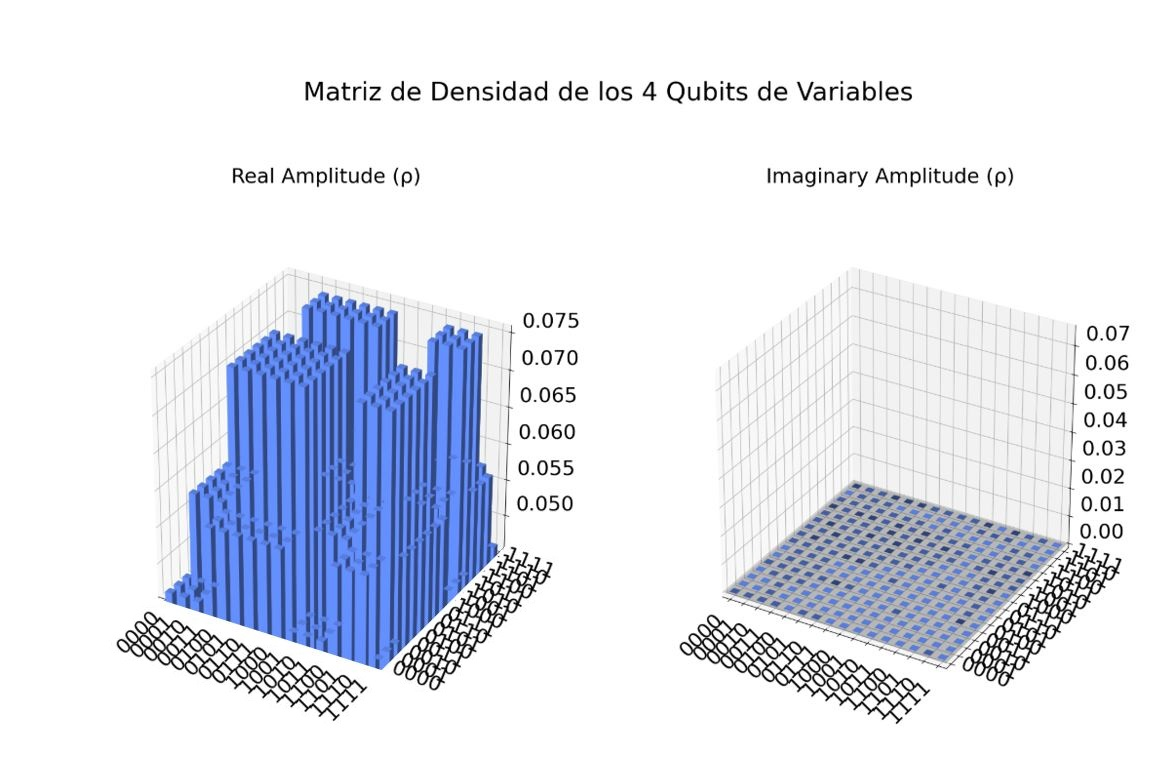

In [50]:
from IPython.display import Image, display

print("Mostrando la 'City Plot' ajustada gráficamente:")

image_path = 'Resultado 3SAT city 1v.JPG'

try:
    display(Image(filename=image_path))
except FileNotFoundError:
    print(f"Error: No se encontró la imagen en '{image_path}'.")

In [46]:
!pip install qiskit-ibm-provider


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import transpile
from qiskit_ibm_runtime import Session, SamplerV2

In [48]:
# --- Paso 1: Guardar la cuenta localmente (opcional) ---
QiskitRuntimeService.save_account(
    channel = "ibm_cloud",
    token   = "yUeCJA6HQy3dMsERue4SuGiOqxV629ivCvjA3diQEQfP",     # reemplaza con tu token real (cadena larga)
    instance = "crn:v1:bluemix:public:quantum-computing:us-east:a/d2f9bb2572764344be2867623b3caf82:6efa08cc-52d5-45f4-901a-16a31ba092c2::",  # reemplaza con tu CRN real
    set_as_default = True,
    overwrite = True
)

# --- Paso 2: Instanciar el servicio (usa la cuenta guardada) ---
service = QiskitRuntimeService()


print("Servicio inicializado correctamente:", service)

# Ver los backends disponibles
print("Backends disponibles:", service.backends())


Servicio inicializado correctamente: <QiskitRuntimeService>
Backends disponibles: [<IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_torino')>]


In [49]:
backend = service.get_backend("ibm_torino")
print("Datos del backend:", backend.properties())


Datos del backend: <qiskit.providers.models.backendproperties.BackendProperties object at 0x0000018E7F3767E0>
